In [23]:
from __future__ import annotations

# import os
# os.chdir (r'C:\userdata\script')s

from typing import Dict, Iterable, List, Mapping, Tuple, Union, Optional
from utils.hierarchy_explorer import DictExplorer
from utils.iterutils import *
from matplotlib import pyplot as plt
from skimage.color import rgb2lab, lab2rgb
import numpy as np, math, colorsys, re

# https://www.color-name.com/tools/color-palette-generator

In [24]:
def is_light(color, threshold=0.5):
    r, g, b = color
    r /= 255
    g /= 255
    b /= 255

    def linearize(c):
        return c / 12.92 if c <= 0.04045 else ((c + 0.055) / 1.055) ** 2.4

    r, g, b = map(linearize, (r, g, b))
    luminance = 0.2126*r + 0.7152*g + 0.0722*b

    return luminance > threshold, luminance, "light" if luminance > 0.667 else "soft" if luminance > 0.333 else "deep"

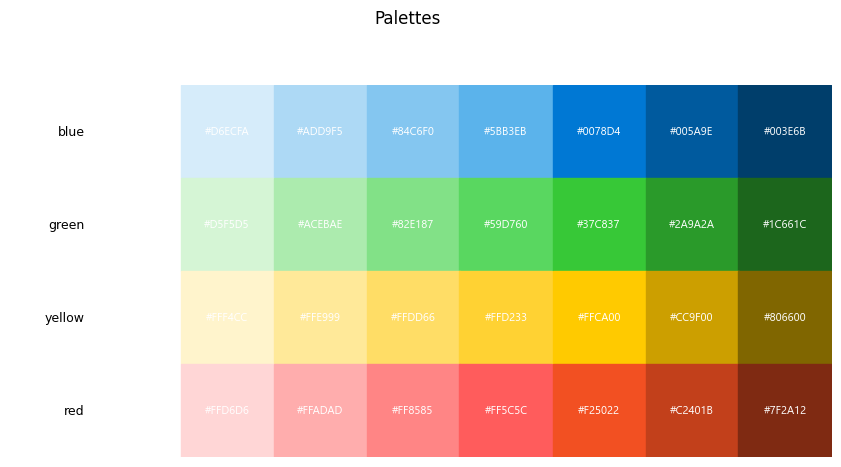

In [40]:
show_shades(super_palette['corporate']['microsoft'])

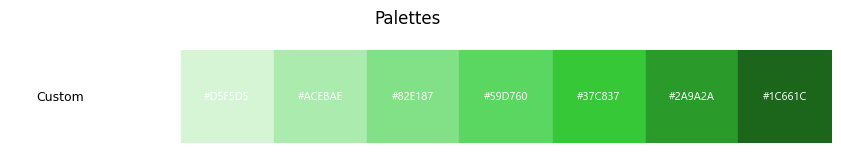

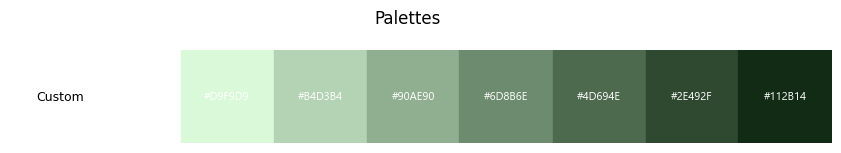

C:\Users\laksl\AppData\Local\Temp\ipykernel_23316\444350936.py:74: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 1 negative Z values that have been clipped to zero
  rgb01 = lab2rgb(new_lab)[0, 0]


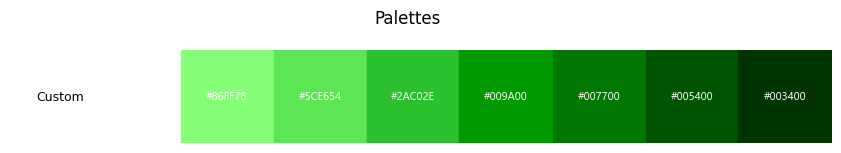

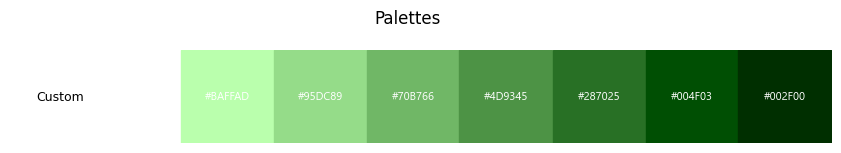

['#BAFFAD', '#95DC89', '#70B766', '#4D9345', '#287025', '#004F03', '#002F00']

In [25]:
show_shades (super_palette['corporate']['microsoft']['green'])
generate_shade (super_palette['corporate']['microsoft']['green'][0], 7, include_base=False)
generate_shade (super_palette['corporate']['microsoft']['green'][4], 7, include_base=False)
generate_shade (super_palette['corporate']['microsoft']['green'][-1], 7, include_base=False)

In [26]:
schemes = {}
for s in ['classic', 'corporate']:
    _schemes = {}
    for key, value in super_palette[s].items():
        if isinstance (value, dict):
            out = {}
            for k, v in value.items():
                _out = {}
                for i in v:
                    color = is_light(hex_to_rgb (v[0]))
                    _out [i] = color[1]
                out[k] = sorted (_out, key=lambda x: x[1], reverse=True)[-1]
        else:
            for i in value:
                color = is_light(hex_to_rgb (v[0]))
                _out [i] = color[1]
                out = sorted (_out, key=lambda x: x[1], reverse=True)[-1]
        _schemes[key] = out
    schemes[s] = _schemes

In [27]:
super_palette = {

	'classic': {
		# Rainbow Scheme
		"rainbow": {
			"red":     ["#FFCCCC", "#FF9999", "#FF6666", "#FF3333", "#FF0000", "#CC0000", "#800000"],
			"orange":  ["#FFE0CC", "#FFC299", "#FFA366", "#FF8533", "#FF6600", "#CC5200", "#803300"],
			"yellow":  ["#FFF7CC", "#FFEF99", "#FFE766", "#FFDF33", "#FFD700", "#CCAC00", "#806F00"],
			"green":   ["#CCF7CC", "#99EF99", "#66E766", "#33DF33", "#00D700", "#00A900", "#006600"],
			"cyan":    ["#CCF7FF", "#99EFFF", "#66E7FF", "#33DFFF", "#00D7FF", "#00A9CC", "#006688"],
			"blue":    ["#CCD9FF", "#99B3FF", "#668CFF", "#3366FF", "#0040FF", "#0033CC", "#001A80"],
			"violet":  ["#E9CCFF", "#D399FF", "#BD66FF", "#A733FF", "#9100FF", "#7300CC", "#4C0080"]
		},
		
		# vibgyor
		"vibgyor": {
			"violet":  ["#E9CCFF", "#D399FF", "#BD66FF", "#A733FF", "#9100FF", "#7300CC", "#4C0080"],
			"indigo":  ["#D6CCFF", "#B399FF", "#8F66FF", "#6B33FF", "#4700FF", "#3900CC", "#260088"],
			"blue":    ["#CCD9FF", "#99B3FF", "#668CFF", "#3366FF", "#0040FF", "#0033CC", "#001A80"],
			"green":   ["#CCF7CC", "#99EF99", "#66E766", "#33DF33", "#00D700", "#00A900", "#006600"],
			"yellow":  ["#FFF7CC", "#FFEF99", "#FFE766", "#FFDF33", "#FFD700", "#CCAC00", "#806F00"],
			"orange":  ["#FFE0CC", "#FFC299", "#FFA366", "#FF8533", "#FF6600", "#CC5200", "#803300"],
			"red":     ["#FFCCCC", "#FF9999", "#FF6666", "#FF3333", "#FF0000", "#CC0000", "#800000"]
		},	

		# TRAFFIC LIGHT
		"traffic_light": {
			"green":   ["#CCF7CC", "#99EF99", "#66E766", "#33DF33", "#00D700", "#00A900", "#006600"],
			"amber":   ["#FFECCC", "#FFD999", "#FFC666", "#FFB333", "#FFA000", "#CC8000", "#805300"],
			"red":     ["#FFCCCC", "#FF9999", "#FF6666", "#FF3333", "#FF0000", "#CC0000", "#800000"]
		},

		# CLASSIC COLOR THEORY SCHEMES
		"classic": {
			"monochromatic_blue": ["#E0ECFF", "#B3D1FF", "#80B5FF", "#4D99FF", "#1A7DFF", "#005FCC", "#003D80"],
			"analogous_blue_teal": ["#CCF7FF", "#99EFFF", "#66E7FF", "#33DFFF", "#00D7FF", "#00A9CC", "#006688"],
			"complementary_blue_orange": ["#CCD9FF", "#99B3FF", "#668CFF", "#3366FF", "#FFB266", "#FF9933", "#FF8000"],
			"triadic_rgb": ["#FF6666", "#FF3333", "#FF0000", "#66FF66", "#33FF33", "#00FF00", "#6666FF"],
			"tetradic_red_blue_green_yellow": ["#FF3333", "#FF0000", "#3366FF", "#0040FF", "#33DF33", "#00D700", "#FFD700"]
		},

		# SCIENTIFIC / DATA‑VIZ SCHEMES
		"dataviz": {
			"sequential_blue": ["#F0F6FF", "#D6E8FF", "#BBD9FF", "#80B5FF", "#4D99FF", "#1A7DFF", "#005FCC"],
			"diverging_red_blue": ["#B2182B", "#D6604D", "#F4A582", "#FDDBC7", "#D1E5F0", "#92C5DE", "#4393C3"],
			"qualitative_8": ["#E41A1C", "#377EB8", "#4DAF4A", "#984EA3","#FF7F00", "#FFFF33", "#A65628", "#F781BF"]
		},

		# DESIGN‑INDUSTRY SCHEMES
		"design": {
			"material_blue": ["#E3F2FD", "#BBDEFB", "#90CAF9", "#64B5F6", "#42A5F5", "#1E88E5", "#0D47A1"],
			"flat_ui": ["#1ABC9C", "#16A085", "#2ECC71", "#27AE60", "#3498DB", "#2980B9", "#9B59B6"],
			"nord": ["#ECEFF4", "#D8DEE9", "#B48EAD", "#88C0D0", "#81A1C1", "#5E81AC", "#4C566A"]
		},
	},

    'corporate': {

		# ANZ (Australia & New Zealand Banking Group)
		# Primary brand blue: #0078D4
		"anz": ["#D6ECFA", "#ADD9F5", "#84C6F0", "#5BB3EB", "#329FE6", "#0078D4", "#005A9E"],

		# Microsoft
		# Four-tile colors: Blue, Green, Yellow, Red
		'microsoft': {
			"blue": ["#D6ECFA", "#ADD9F5", "#84C6F0", "#5BB3EB", "#0078D4", "#005A9E", "#003E6B"],
			"green": ["#D5F5D5", "#ACEBAE", "#82E187", "#59D760","#37C837", "#2A9A2A", "#1C661C"],
			"yellow": ["#FFF4CC", "#FFE999", "#FFDD66", "#FFD233","#FFCA00", "#CC9F00", "#806600"], 
			"red": ["#FFD6D6", "#FFADAD", "#FF8585", "#FF5C5C","#F25022", "#C2401B", "#7F2A12"],
		},
		
		# Google
		# Primary colors: Blue, Red, Yellow, Green
		'google': {
			"blue": ["#D6E8FF", "#ADD1FF", "#84BAFF", "#5BA3FF", "#4285F4", "#3367C2", "#22458A"],
			"red": ["#FFD6D6", "#FFADAD", "#FF8585", "#FF5C5C", "#DB4437", "#A53329", "#6B221C"],
			"yellow": ["#FFF4CC", "#FFE999", "#FFDD66", "#FFD233", "#F4B400", "#C28E00", "#7F5E00"],
			"green": [ "#D5F5D5", "#ACEBAE", "#82E187", "#59D760", "#0F9D58", "#0B7441", "#074D2B"],
		},

		# Instagram
		# Brand uses a gradient; we anchor to its core hues:
		# Purple, Magenta, Orange
		'insta': {
			"purple": ["#E9CCFF", "#D399FF", "#BD66FF", "#A733FF", "#833AB4", "#642C87", "#3F1A52"],
			"magenta": ["#FFCCF2", "#FF99E6", "#FF66D9", "#FF33CC", "#C13584", "#922864", "#5C173D"],
			"orange": ["#FFE0CC", "#FFC299", "#FFA366", "#FF8533","#FD7E14", "#C56210", "#7F3F0A" ],
		},

		# IBM (iconic blue)
		'ibm': ["#D6E8FF", "#ADD1FF", "#84BAFF", "#5BA3FF","#054ADA", "#0438A5", "#03256E"],

		# Coca-Cola (classic red)
		"cocacola": ["#FFD6D6", "#FFADAD", "#FF8585", "#FF5C5C", "#E41A1C", "#B11315", "#6E0C0D"],

		# Spotify (distinctive green)
		"spotify": ["#D5F5D5", "#ACEBAE", "#82E187", "#59D760", "#1DB954", "#158A3F", "#0E5C2A"],
    
        "tesla": ["#FBDADF", "#F5A7B3", "#F07486", "#EA405A", "#E31937", "#A61228", "#730D1C"],
    
        "amazon": {
            "orange": ["#FFEFD6", "#FFD89D", "#FFC164", "#FFAA2B", "#FF9900", "#B86F00", "#804C00"],
            "slate": ["#E5EAF0", "#C1CDDC", "#9CAFC7", "#7892B3", "#57759A", "#435976", "#232F3E"]
        },

        "gardens": ["#FCD9E4", "#F7A5BD", "#F37097", "#EF3C70", "#E21350", "#AA0E3C", "#760A2A"],
    
        "ebay": {
            "red": ["#FAD7D9", "#F4A3A8", "#EE6F77", "#E53238", "#C6282D", "#9C1F23", "#6F1619"],
            "blue": ["#D6ECFA", "#A3D0F4", "#6FB3EE", "#3C96E5", "#0064D2", "#004BA0", "#00336E"],
            "yellow": ["#FFF3D6", "#FFE19D", "#FFD064", "#FFBE2B", "#F5AF02", "#B88502", "#7A5801"],
            "green": ["#E0F5E8", "#AEE6C2", "#7CD69C", "#4AC777", "#2DBE60", "#22904A", "#176334"]
        },

        "nbc": {
            "yellow": ["#FFF4D6", "#FFE49D", "#FFD564", "#FFC52B", "#FFB900", "#B88600", "#805C00"],
            "orange": ["#FFE6D1", "#FFC7A1", "#FFA871", "#FF8941", "#FF6A00", "#C65300", "#8A3A00"],
            "red": ["#FAD9DC", "#F5A6AE", "#F07380", "#EB4052", "#E60026", "#AF001E", "#790015"],
            "purple": ["#F0E3F7", "#D5B9EC", "#BB8EE1", "#A064D6", "#8E44AD", "#6C3383", "#4A235A"],
            "blue": ["#E0F0FA", "#ADD7F0", "#7ABEE6", "#47A5DC", "#2196F3", "#1A74BD", "#124F83"],
            "green": ["#E6F4DF", "#BFE5B3", "#98D687", "#71C85B", "#4CAF50", "#3A863D", "#275C2A"]
        },
	}
}



emotions = {
        "optimistic": ["#FFF6D6", "#FFE9A3", "#FFDC70", "#FFCF3D", "#FFC107", "#C69505", "#8A6603"],
        "friendly": ["#FFE6D1", "#FFC7A1", "#FFA871", "#FF8941", "#FF6A00", "#C65300", "#8A3A00"],
        "excited": ["#FAD9DC", "#F5A6AE", "#F07380", "#EB4052", "#E60026", "#AF001E", "#790015"],
        "creative": ["#F0E3F7", "#D5B9EC", "#BB8EE1", "#A064D6", "#8E44AD", "#6C3383", "#4A235A"],
        "trusted": ["#E0F0FA", "#ADD7F0", "#7ABEE6", "#47A5DC", "#2196F3", "#1A74BD", "#124F83"],
        "peaceful": ["#E6F4DF", "#BFE5B3", "#98D687", "#71C85B", "#4CAF50", "#3A863D", "#275C2A"],
        "balance": ["#F2F2F2", "#D9D9D9", "#BFBFBF", "#A6A6A6", "#8C8C8C", "#666666", "#404040"]
}
aliases = {'optimistic': ['clear', 'warm'],
     'friendly': ['cheerful', 'confident'],
     'excited': ['youthful', 'bold'],
     'creative': ['imaginative', 'wise'],
     'trusted': ['dependable', 'strong'],
     'peaceful': ['growth', 'healthy'],
     'balance': ['neutral', 'calm']}

emotions['emotions'] = {}
for base, names in aliases.items():
    for alias in names:
        emotions[alias] = emotions[base]
        emotions['emotions'][base] = emotions[base]
        
color_map = {
    'aliceblue': '#f0f8ff', 'amaranth': '#e52b50', 'amber': '#ffbf00', 'amethyst': '#9966cc', 'antiquewhite': '#faebd7',
    'apricot': '#fbceb1', 'aqua': '#00ffff', 'asparagus': '#87a96b', 'aureolin': '#fdee00', 'beaver': '#9f8170',
    'beige': '#f5f5dc', 'bistre': '#3d2b1f', 'bittersweet': '#fe6f5e', 'black': '#000000', 'blanchedalmond': '#ffebcd',
    'blond': '#faf0be', 'blueviolet': '#8a2be2', 'bole': '#79443b', 'bone': '#e3dac9', 'boysenberry': '#873260',
    'brass': '#b5a642', 'bronze': '#cd7f32', 'brown': '#a52a2a', 'buff': '#f0dc82', 'burgundy': '#800020',
    'burlywood': '#deb887', 'byzantine': '#bd33a4', 'byzantium': '#702963', 'cadetblue': '#5f9ea0', 'camel': '#c19a6b',
    'canary': '#ffff99', 'cardinal': '#c41e3a', 'carmine': '#960018', 'carnelian': '#b31b1b', 'celadon': '#ace1af',
    'celeste': '#b2ffff', 'cerise': '#de3163', 'cerulean': '#007ba7', 'chamoisee': '#a0785a', 'champagne': '#f7e7ce',
    'charcoal': '#36454f', 'chestnut': '#954535', 'chocolate': '#d2691e', 'cinereous': '#98817b', 'cinnabar': '#e34234',
    'citrine': '#e4d00a', 'citron': '#9fa91f', 'claret': '#7f1734', 'cobalt': '#0047ab', 'coffee': '#6f4e37',
    'copper': '#b87333', 'coquelicot': '#ff3800', 'coral': '#ff7f50', 'cordovan': '#893f45', 'corn': '#fbec5d',
    'cornflowerblue': '#6495ed', 'cream': '#fffdd0', 'crimson': '#dc143c', 'crystal': '#a7d8de', 'cyclamen': '#f56fa1',
    'daffodil': '#ffff31', 'dandelion': '#f0e130', 'darkgoldenrod': '#b8860b', 'darkgreen': '#006400', 'darkkhaki': '#bdb76b',
    'darkolivegreen': '#556b2f', 'darkorange': '#ff8c00', 'darkorchid': '#9932cc', 'darksalmon': '#e9967a', 'darkseagreen': '#8fbc8f',
    'darkslateblue': '#483d8b', 'darkslategray': '#2f4f4f', 'darkturquoise': '#00ced1', 'darkviolet': '#9400d3', 'denim': '#1560bd',
    'dimgray': '#696969', 'ebony': '#555d50', 'eggplant': '#614051', 'eggshell': '#f0ead6', 'emerald': '#50c878',
    'eminence': '#6c3082', 'fawn': '#e5aa70', 'feldgrau': '#4d5d53', 'firebrick': '#b22222', 'floralwhite': '#fffaf0',
    'forestgreen': '#228b22', 'frostbite': '#e936a7', 'fulvous': '#e48400', 'gainsboro': '#dcdcdc', 'gamboge': '#e49b0f',
    'ghostwhite': '#f8f8ff', 'ginger': '#b06500', 'glaucous': '#6082b6', 'goldenrod': '#daa520', 'gray': '#bebebe',
    'greenyellow': '#adff2f', 'grullo': '#a99a86', 'gunmetal': '#2a3439', 'harlequin': '#3fff00', 'heliotrope': '#df73ff',
    'hotpink': '#ff69b4', 'iceberg': '#71a6d2', 'icterine': '#fcf75e', 'inchworm': '#b2ec5d', 'indianred': '#cd5c5c',
    'indigo': '#4b0082', 'iris': '#5a4fcf', 'isabelline': '#f4f0ec', 'jade': '#00a86b', 'jasmine': '#f8de7e',
    'jonquil': '#f4ca16', 'keppel': '#3ab09e', 'khaki': '#f0e68c', 'lavender': '#e6e6fa', 'lawngreen': '#7cfc00',
    'lemon': '#fff700', 'light': '#eedd82', 'lightblue': '#add8e6', 'lightcoral': '#f08080', 'lightgoldenrodyellow': '#fafad2',
    'lightgray': '#d3d3d3', 'lightpink': '#ffb6c1', 'lightseagreen': '#20b2aa', 'lightskyblue': '#87cefa', 'lightslateblue': '#8470ff',
    'lightslategray': '#778899', 'lightsteelblue': '#b0c4de', 'lilac': '#c8a2c8', 'limegreen': '#32cd32', 'linen': '#faf0e6',
    'magenta': '#ff00ff', 'mahogany': '#c04000', 'malachite': '#0bda51', 'manatee': '#979aaa', 'mandarin': '#f37a48',
    'mango': '#fdbe02', 'mantis': '#74c365', 'marigold': '#eaa221', 'maroon': '#b03060', 'mauve': '#e0b0ff',
    'mauvelous': '#ef98aa', 'medium': '#66cdaa', 'mediumaquamarine': '#66cdaa', 'mediumblue': '#0000cd', 'mediumorchid': '#ba55d3',
    'mediumpurple': '#9370db', 'mediumseagreen': '#3cb371', 'mediumslateblue': '#7b68ee', 'mediumspringgreen': '#00fa9a', 'mediumturquoise': '#48d1cc',
    'mediumvioletred': '#c71585', 'melon': '#febaad', 'midnightblue': '#191970', 'mindaro': '#e3f988', 'mint': '#3eb489',
    'mintcream': '#f5fffa', 'moccasin': '#ffe4b5', 'mulberry': '#c54b8c', 'mustard': '#ffdb58', 'navyblue': '#000080',
    'nickel': '#727472', 'nyanza': '#e9ffdb', 'ochre': '#cc7722', 'oldlace': '#fdf5e6', 'olive': '#808000',
    'olivedrab': '#6b8e23', 'olivine': '#9ab973', 'opal': '#a8c3bc', 'orchid': '#da70d6', 'oxblood': '#4a0000',
    'pale': '#db7093', 'palegoldenrod': '#eee8aa', 'palegreen': '#98fb98', 'paleturquoise': '#afeeee', 'palevioletred': '#db7093',
    'papayawhip': '#ffefd5', 'peach': '#ffe5b4', 'pear': '#d1e231', 'pink': '#ffc0cb', 'pistachio': '#93c572',
    'platinum': '#e5e4e2', 'plum': '#8e4585', 'powderblue': '#b0e0e6', 'puce': '#cc8899', 'pumpkin': '#ff7518',
    'purple': '#a020f0', 'raspberry': '#e30b5d', 'razzmatazz': '#e3256b', 'rebeccapurple': '#663399', 'redwood': '#a45a52',
    'rose': '#ff007f', 'rosewood': '#65000b', 'rosybrown': '#bc8f8f', 'royalblue': '#4169e1', 'ruby': '#e0115f',
    'russet': '#80461b', 'rust': '#b7410e', 'saddlebrown': '#8b4513', 'saffron': '#f4c430', 'sage': '#bcb88a',
    'salmon': '#fa8072', 'sandybrown': '#f4a460', 'sapphire': '#0f52ba', 'scarlet': '#ff2400', 'sepia': '#704214',
    'sienna': '#a0522d', 'silver': '#c0c0c0', 'sinopia': '#cb410b', 'skobeloff': '#007474', 'skyblue': '#87ceeb',
    'slateblue': '#6a5acd', 'slategray': '#708090', 'steelblue': '#4682b4', 'straw': '#e4d96f', 'sunglow': '#ffcc33',
    'tan': '#d2b48c', 'tangerine': '#f28500', 'taupe': '#483c32', 'teal': '#008080', 'thistle': '#d8bfd8',
    'timberwolf': '#dbd7d2', 'tumbleweed': '#deaa88', 'turquoise': '#40e0d0', 'tuscany': '#c09999', 'ultramarine': '#3f00ff',
    'vanilla': '#f3e5ab', 'verdigris': '#43b3ae', 'vermillion': '#e34234', 'violet': '#ee82ee', 'violetred': '#d02090',
    'viridian': '#40826d', 'volt': '#ceff00', 'wheat': '#f5deb3', 'white': '#ffffff', 'whitesmoke': '#f5f5f5',
    'wine': '#722f37', 'wisteria': '#c9a0dc', 'xanadu': '#738678', 'yellowgreen': '#9acd32', 'zaffre': '#0014a8',
    'zomp': '#39a78e'}

In [28]:
def visualize(func=None, *, display=True):
    def decorator(func):
        @wraps(func)
        def wrapper(*args, **kwargs):
            show = kwargs.pop("display", display)   # ⬅️ FIX: pop first
            shade = func(*args, **kwargs)
            if show:
                show_shades(shade)
            return shade
        return wrapper

    if callable(func):
        return decorator(func)

    return decorator

def show_shades(palettes: Union[str, List[str], Mapping[str, List[str]],  Mapping[str, Mapping[str, List[str]]]],
                *,
                show_hex: bool = True, title: str = "Palettes", title_px: int = 60, 
                cell_px: int = 120, max_cols: int = 10, max_rows: int = 10, dpi: int = 100,
                row_label_px: int = 220, font_family=None, font_size: int = 8, font_color = None) -> None:
    """Render palette rows using fixed-size square cells; paginate instead of shrinking."""    

    def normalize_nested(palettes: Union[str, List[str], Mapping[str, List[str]]]) -> Dict[str, Dict[str, List[str]]]:
        """Normalize palette input into {palette_name: {row_name: [#RRGGBB...]}}."""
        if isinstance(palettes, str):
            return {"Palette": {"Custom": _as_row(palettes)}}
    
        # ✅ accept list/tuple of hex, rgb, or mixed
        if isinstance(palettes, (list, tuple)):
            return {"Palette": {"Custom": _as_row(list(palettes))}}
    
        if isinstance(palettes, dict):
            if all(not isinstance(v, dict) for v in palettes.values()):
                return {"Palette": {k: _as_row(v) for k, v in palettes.items()}}  # type: ignore[arg-type]
            return {p: {k: _as_row(v) for k, v in rows.items()} for p, rows in palettes.items()}  # type: ignore[union-attr]
    
        raise TypeError("Unsupported palette structure")
    

    def _rgb_to_hex(rgb: tuple[int, int, int]) -> str:
        r, g, b = rgb
        return f"#{r:02X}{g:02X}{b:02X}"
    
    def _is_rgb(x: object) -> bool:
        if not isinstance(x, (tuple, list)) or len(x) != 3:
            return False
        return all(isinstance(c, int) and 0 <= c <= 255 for c in x)
    
    def _is_hex(s: object) -> bool:
        if not (isinstance(s, str) and s.startswith("#") and len(s) == 7):
            return False
        return all(ch in "0123456789abcdefABCDEF" for ch in s[1:])
    
    def _as_row(v: object, *, placeholder: str = "#EEEEEE") -> List[str]:
        """Return a list of #RRGGBB; accepts hex strings and RGB (r,g,b) triples."""
        # single value
        if _is_hex(v):
            return [v]  # type: ignore[list-item]
        if _is_rgb(v):
            return [_rgb_to_hex(tuple(v))]  # type: ignore[arg-type]
    
        # list of values (mix of hex + rgb)
        if isinstance(v, list):
            out: List[str] = []
            for x in v:
                if _is_hex(x):
                    out.append(x)
                elif _is_rgb(x):
                    out.append(_rgb_to_hex(tuple(x)))  # type: ignore[arg-type]
            return out or [placeholder]
    
        # other iterables (e.g., tuples, generators)
        if hasattr(v, "__iter__") and not isinstance(v, (str, bytes, dict)):
            try:
                out: List[str] = []
                for x in list(v):  # type: ignore[arg-type]
                    if _is_hex(x):
                        out.append(x)
                    elif _is_rgb(x):
                        out.append(_rgb_to_hex(tuple(x)))  # type: ignore[arg-type]
                return out or [placeholder]
            except TypeError:
                return [placeholder]
    
        return [placeholder]
    
    data = normalize_nested(palettes)
    
    for pname, rows in data.items():
        items = list(rows.items())
        rows_total = len(items)
        cols_total = max((len(cs) for _, cs in items), default=0)

        row_pages = max(1, math.ceil(rows_total / max_rows))
        col_pages = max(1, math.ceil(cols_total / max_cols))

        for rp in range(row_pages):
            r0, r1 = rp * max_rows, min(rows_total, (rp + 1) * max_rows)
            page_rows = items[r0:r1]
            h = len(page_rows)

            for cp in range(col_pages):
                c0, c1 = cp * max_cols, min(cols_total, (cp + 1) * max_cols)
                w = c1 - c0

                fig_w = (row_label_px + w * cell_px) / dpi
                fig_h = (title_px + h * cell_px) / dpi
                fig, ax = plt.subplots(figsize=(fig_w, fig_h), dpi=dpi)
                ax.set_aspect("equal")
                ax.set_xlim(-row_label_px / cell_px, w)
                ax.set_ylim(0, h)
                ax.axis("off")

                for r, (row_name, colors) in enumerate(page_rows):
                    y = h - r - 1
                    ax.text( -0.2 - (row_label_px / cell_px - 1), y + 0.5,
                             row_name, ha="right", va="center", fontsize=font_size+1)
                    for c in range(w):
                        idx = c0 + c
                        if idx >= len(colors):
                            continue
                        hexcode = colors[idx]
                        ax.add_patch(plt.Rectangle((c, y), 1, 1, color=hexcode))
                        if show_hex:
                            ax.text(c + 0.5, y + 0.5, hexcode, ha="center", va="center", 
                                    fontsize=font_size, color = font_color or "#FFFFFF", fontfamily=font_family or "Segoe UI")

                suffix = ""
                if row_pages > 1 or col_pages > 1:
                    suffix = f" (rows {r0+1}-{r1}, cols {c0+1}-{c1})"
                fig.suptitle(f"{title}", y=0.98)
                plt.show()


In [29]:
@iterexec(tuple_is_autonomic=True)
def rgb_to_hex(rgb):
    return "#{:02X}{:02X}{:02X}".format(*rgb)

def hex_to_rgb(hexcode):
    hexcode = hexcode.lstrip("#")
    return tuple(int(hexcode[i:i+2], 16) for i in (0, 2, 4))

def relative_luminance(rgb):
    f = lambda c: c/12.92 if c <= 0.03928 else ((c+0.055)/1.055)**2.4
    r, g, b = [x/255 for x in rgb]
    R, G, B = f(r), f(g), f(b)
    return 0.2126*R + 0.7152*G + 0.0722*B

def contrast_ratio(c1, c2):
    L1 = relative_luminance(c1)
    L2 = relative_luminance(c2)
    L1, L2 = max(L1, L2), min(L1, L2)
    return (L1 + 0.05) / (L2 + 0.05)

In [30]:
@visualize
def generate_shade(base, shades=5, return_type="hex",
                   preset=None,
                   mode="lab",          # "lightness", "saturation", "hue", "lab"
                   direction="both",
                   hue_shift=0,
                   include_base=True):
    """
    Generate N evenly spaced shades from a base color.
    Supports hex or rgb input. Modes: lightness, saturation, hue, lab.
    """

    def clamp(x, lo=0, hi=1):
        return max(lo, min(hi, x))    

    # normalize base to RGB tuple[int,int,int]
    base_rgb = hex_to_rgb(base) if isinstance(base, str) else base
    r, g, b = [x / 255 for x in base_rgb]
    h, l, s = colorsys.rgb_to_hls(r, g, b)
    h = (h + hue_shift / 360) % 1

    _presets = {
        "tint": ("lightness", "lighter"),
        "shade": ("lightness", "darker"),
        "tone": ("saturation", "darker"),
        "vibrant": ("saturation", "lighter"),
        "muted": ("saturation", "darker"),
    }
    if preset:
        mode, direction = _presets[preset]

    results = []

    if mode == "lightness":
        if direction == "lighter":
            values = [l + i * (1 - l) / (shades - 1) for i in range(shades)]
        elif direction == "darker":
            values = [l - i * (l - 0) / (shades - 1) for i in range(shades)]
        else:
            values = [clamp(0.1 + i * (0.8 / (shades - 1))) for i in range(shades)]

        for new_l in values:
            nr, ng, nb = colorsys.hls_to_rgb(h, new_l, s)
            results.append((int(nr * 255), int(ng * 255), int(nb * 255)))

    elif mode == "saturation":
        if direction == "lighter":
            values = [s + i * (1 - s) / (shades - 1) for i in range(shades)]
        elif direction == "darker":
            values = [s - i * (s - 0) / (shades - 1) for i in range(shades)]
        else:
            values = [clamp(0.1 + i * (0.8 / (shades - 1))) for i in range(shades)]

        for new_s in values:
            nr, ng, nb = colorsys.hls_to_rgb(h, l, new_s)
            results.append((int(nr * 255), int(ng * 255), int(nb * 255)))

    elif mode == "hue":
        values = [(h + (i * (1 / shades))) % 1 for i in range(shades)]
        for new_h in values:
            nr, ng, nb = colorsys.hls_to_rgb(new_h, l, s)
            results.append((int(nr * 255), int(ng * 255), int(nb * 255)))

    elif mode == "lab":
        base_rgb01 = np.array(base_rgb, dtype=float) / 255.0
        lab = rgb2lab(base_rgb01.reshape(1, 1, 3))[0, 0]
        L, a_, b_ = lab

        # light → dark (perceptually smoother). Keeps a*, b* constant like your smooth_shades.
        L_values = np.linspace(95, 15, shades)

        for new_L in L_values:
            new_lab = np.array([new_L, a_, b_]).reshape(1, 1, 3)
            rgb01 = lab2rgb(new_lab)[0, 0]
            rgb255 = tuple((rgb01 * 255).clip(0, 255).astype(int))
            results.append(rgb255)

    else:
        raise ValueError(f"Unknown mode: {mode}")

    # --- finalize output ---
    out = [rgb_to_hex(c) for c in results] if return_type == "hex" else results
    if include_base:
        base_out = base if return_type == "hex" and isinstance(base, str) else (rgb_to_hex(base_rgb) if return_type == "hex" else base_rgb)
        return [base_out] + out
    return out

def generate_contrast_shades(
    base: Union[str, Tuple[int, int, int]],
    bg: Tuple[int, int, int] = (255, 255, 255),
    target: float = 4.5, steps: int = 7, return_type: str = "hex") -> List[Union[str, Tuple[int, int, int]]]:
    """
    Generate a perceptually ordered set of shades that meet a contrast threshold.

    Starting from a base color, this function generates a Lab-space shade ramp
    and returns only those shades whose contrast ratio against the given
    background meets or exceeds the target value.
    """
    # Generate perceptually uniform ramp once (Lab)
    ramp = generate_shade(base, shades=steps, mode='lab', return_type="rgb", display=False)

    # Filter by contrast
    filtered = [c for c in ramp if contrast_ratio(c, bg) >= target]

    if return_type == "hex":
        return rgb_to_hex(filtered)
    return filtered

def font_color(base: Sequence[Union[str, Tuple[int, int, int]]],
               seq: int = 1, inverted: bool = False, font_family: Optional[str] = None, **kwargs) -> Tuple[Color, Color]:
    """
    Derive a background/foreground color pair with sufficient contrast.

    Selects a reference color from `base`, generates a contrast ramp, and
    returns a `(background, foreground)` pair. Optionally inverts the pair
    for reversed contrast usage.
    """
    # normalize index safely
    idx = -seq if seq <= len(base) else -1
    ref = base[idx]

    # generate once; suppress visualization at source
    shades = generate_contrast_shades(ref, target=1, steps=7, display=False)

    bg, fg = shades[-seq], shades[seq]
    if inverted:
        bg, fg = fg, bg

    # forward optional font_family to visualization only
    show_kwargs = {"font_color": fg}
    if font_family:
        show_kwargs["font_family"] = font_family

    show_shades(bg, **show_kwargs, **kwargs)

    return bg, fg

In [31]:
def layer_shades(shades: Sequence[Union[str, Tuple[int, int, int]]],
                 n: Optional[int] = 4) -> List[Union[str, Tuple[int, int, int]]]:
    """
    Pick evenly spaced shades from an ordered palette for layered use.

    Returns up to `n` representative shades (centered and evenly distributed)
    from the input palette. If `n` exceeds the palette size, the darkest shade
    is repeated. If `n` is None (or the input is a single RGB tuple), the palette
    is returned unchanged.
    """
    if not isinstance(shades, (list, tuple)):
        raise ValueError("shades must be a list or tuple of color values")

    if not shades:
        return []

    # passthrough: no layering requested or single RGB tuple
    if n is None or (isinstance(shades, tuple) and isinstance(shades[0], int)):
        return list(shades)

    total = len(shades)

    if n <= 1:
        indices = [total // 2]
    else:
        s = min(n, total)
        indices = [int(i * (total - 1) / (s - 1)) for i in range(s)]
        indices += [total - 1] * max(n - s, 0)

    return [shades[i] for i in indices]

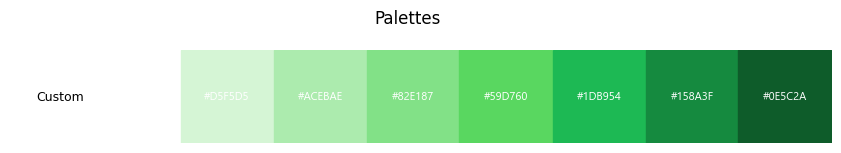

In [63]:
show_shades(super_palette['corporate']['spotify'])

In [54]:
show_shades(super_palette['corporate']['

dict_keys(['anz', 'microsoft', 'google', 'insta', 'ibm', 'cocacola', 'spotify', 'tesla', 'amazon', 'gardens', 'ebay', 'nbc'])

In [32]:
@visualize
def get_list(palette, root=None, display=True):
    ds = cs.get_value(root, palette) if root else palette    
    if isinstance(ds, list): #ds is a list
        return ds
    if not isinstance(ds, dict): # ds is a scalar
        return ds
    # ds is a dict
    out = {}
    for k, v in ds.items():
        if isinstance(v, dict):
            out[k] = ", ".join(v.keys())
        else:
            out[k] = v
    return out

@visualize
def contrast_shades(*shades: Union[Dict[str, List[Any]], List[Any], Tuple[Any, ...]]) -> Dict[str, List[Any]]:
    """
    Normalize one or more shade palettes into a contrast-ready mapping.

    - If given a single palette, returns the palette and its reversed contrast.
    - If given multiple palettes, returns them labeled as combinations.
    - If given a dict, returns it unchanged.
    """
    # unwrap single container input
    if len(shades) == 1 and isinstance(shades[0], (dict, list, tuple)):
        shades = shades[0]  # type: ignore[assignment]

    if isinstance(shades, dict):
        return shades

    if isinstance(shades, (list, tuple)):
        if len(shades) > 1:
            return {f"combo {i+1}": v for i, v in enumerate(shades)}
        return {
            "original": list(shades),
            "contrast": list(shades)[::-1],
        }

    raise TypeError("Unsupported shades input")

@visualize
def circulant(lst: Sequence[Any], left: bool = True, labels: Optional[Union[str, Sequence[str]]] = None) -> Dict[str, List[Any]]:
    """
    Generate a circulant mapping of an ordered sequence.

    Returns an N×N cyclic rotation of the input sequence, labeled per row.
    Each row is a left or right rotation of the original sequence, preserving order.
    """
    base = list(lst)
    n = len(base)
    if n == 0:
        return {}

    # labels
    if labels is None:
        labels_list = [f"Combo {i}" for i in range(1, n + 1)]
    elif isinstance(labels, str):
        labels_list = [f"{labels} {i}" for i in range(1, n + 1)]
    elif isinstance(labels, (list, tuple)):
        labels_list = list(labels)[:n]
        if len(labels_list) < n:
            labels_list += [f"Combo {i}" for i in range(len(labels_list) + 1, n + 1)]
    else:
        raise TypeError("labels must be None, str, or list/tuple")

    # rotations (avoid extra slicing work for i=0)
    rows = [base] + (
        [base[-i:] + base[:-i] for i in range(1, n)]
        if left
        else [base[i:] + base[:i] for i in range(1, n)]
    )

    return dict(zip(labels_list, rows))


def label_shades(
    shades: Iterable[Union[str, Tuple[int, int, int]]]
) -> Dict[str, Union[str, Tuple[int, int, int]]]:
    """
    Assign semantic names to an ordered sequence of shades.
    """
    semantic = ("ultra_light", "light", "soft", "neutral", "strong", "deep", "contrast",)

     # single atomic shade → base
    if isinstance(shades, (str, tuple)) and not isinstance(shades, list):
        return {"base": shades}

    # materialize once (supports generators)
    items = list(shades)

    if not items:
        return {}

    if len(items) == 1:
        return {"base": items[0]}

    return {
        (semantic[i] if i < len(semantic) else f"shade_{i+1}"): shade
        for i, shade in enumerate(items)
    }

def shade_by_semantic(
    shades: Iterable[Union[str, Tuple[int, int, int]]],
    semantic: Union[str, int],
    labels: Optional[Dict[str, int]] = None,
    order: Optional[Tuple[str, ...]] = None,
) -> Union[str, Tuple[int, int, int]]:
    """
    Return a shade from an ordered ramp using a semantic name or index.
    """
    # default semantic order (light → dark)
    default_order = ("ultra_light", "light", "soft", "neutral", "strong", "deep", "contrast",)

    # default semantic → position (1-based)
    default_labels = {"footnote": 1, "highlight": 2, "upbeat": 3, "neutral": 4, "accent": 5, "somber": 6, "contrast": 7}

    order = order or default_order
    labels = labels or default_labels

    items = list(shades)
    if not items:
        raise ValueError("Empty shades ramp")

    # semantic by index (1-based)
    if isinstance(semantic, int):
        idx = semantic

    # semantic by named position (order)
    elif semantic in order:
        idx = order.index(semantic) + 1

    # semantic via label map
    elif semantic in labels:
        idx = labels[semantic]

    else:
        raise KeyError(f"Unknown semantic: {semantic}")

    # clamp safely
    idx = max(1, min(idx, len(items))) - 1
    return items[idx]
    

In [33]:
cs.save ('super_palette.yaml', fmt='yaml')
cs.save ('super_palette.json', fmt='json')

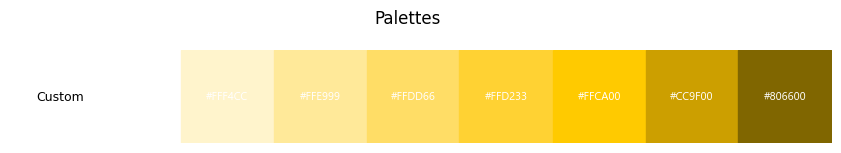

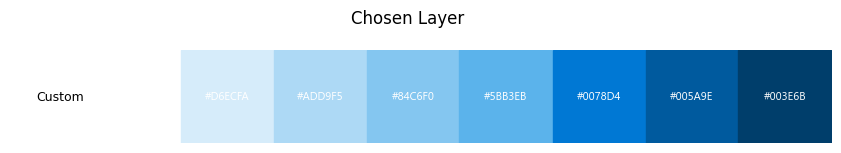

['#FFF4CC', '#FFDD66', '#FFCA00', '#806600']

In [34]:
provider, reqd = cs, 'microsoft.yellow'
show_shades(provider.get(reqd))
res = layer_shades(provider.get(reqd), 4)
show_shades (['#D6ECFA', '#ADD9F5', '#84C6F0', '#5BB3EB', '#0078D4', '#005A9E', '#003E6B'], title='Chosen Layer')
res

In [35]:
@visualize
def normalize (color: Union[str, Iterable[str, tuple]], ret_fmt: str = 'hex', 
               n_shades: Union[int, Tuple[int,int]] = 1, reverse: bool = False):
    
    if isinstance(color, tuple):
        return color if ret_fmt =="rgb" else rgb_to_hex(color)

    if isinstance (color, str) and color.startswith ('#'):
        return color if ret_fmt =="hex" else hex_to_rgb(color)
        
    s, e = ((None, n_shades) if n_shades  >= 1 else (n_shades, None)) if isinstance(n_shades, int) else n_shades
    hex_list = set(cs.get (color))
    result = sorted(hex_list, key=lambda h: relative_luminance(hex_to_rgb(h)), reverse=not reverse)[s:e]    
    
    return result if len(result) > 1 else result[0]
 


In [36]:
cs = DictExplorer (super_palette, get='smart')
hues = DictExplorer (color_map, get='smart')
tones = DictExplorer (emotions, get='smart')

In [37]:
import re
list (filter (lambda x: re.search ('sea', x), hues.get_keys()))

['darkseagreen', 'lightseagreen', 'mediumseagreen']

In [38]:
shade_semantics = {
    "footnote": 1,        # lightest, subtle
    "neutral": 4,         # middle, balanced
    "contrast": 7,        # darkest, strong
    "upbeat": 3,          # bright but not washed out
    "somber": 6,          # deep but not black
    "highlight": 2,       # light, attention-grabbing
    "accent": 5           # strong but not full contrast
}

shade_semantic_bundles = {
    "professional": ["neutral", "contrast"],
    "soft": ["footnote", "neutral"],
    "bold": ["contrast", "accent"],
    "dimmed": ["footnote", "somber"],
    "highlighted": ["highlight", "accent"]
}

emotion_palette_map = {
    "urgent":      ("rainbow", "red", "contrast"),
    "warning":     ("traffic_light", "amber", "contrast"),
    "calm":        ("rainbow", "blue", "neutral"),
    "trust":       ("corporate", "microsoft_blue", "neutral"),
    "success":     ("traffic_light", "green", "accent"),
    "error":       ("traffic_light", "red", "contrast"),
    "celebrate":   ("rainbow", "yellow", "highlight"),
    "somber":      ("rainbow", "violet", "somber")
}

In [39]:
def parse_color_intent(text):
    text = text.lower()

    # 1. Check emotion → palette mapping
    for emo, (base, variant, shade) in emotion_palette_map.items():
        if emo in text:
            return base, variant, shade

    # 2. Check corporate names
    for corp in ["microsoft", "google", "anz", "spotify", "ibm", "cocacola"]:
        if corp in text:
            base = "corporate"
            variant = f"{corp}_blue" if corp == "microsoft" else corp
            # default shade = neutral
            return base, variant, "neutral"

    # 3. Check shade semantics
    for label in shade_semantics:
        if label in text:
            return None, None, label

    # 4. Check bundles
    for bundle in shade_semantic_bundles:
        if bundle in text:
            return None, None, bundle

    return None, None, None

@visualize
def color_intent(text, palettes):
    base, variant, shade = parse_color_intent(text)

    # If bundle → expand into multiple shades
    if shade in shade_semantic_bundles:
        shades = []
        for s in shade_semantic_bundles[shade]:
            shades.append(
                get_my_shade(base, variant, s, palettes)
            )
        show_my_shade(shades)
        return shades

    # Normal single shade
    result = get_my_shade(base, variant, shade, palettes)
    return result

color_intent ('professional', super_palette)

NameError: name 'get_my_shade' is not defined

In [ ]:
contrast_shades(smooth_shades(hues.get('violet'), shades=4, return_type="hex"))

In [ ]:


def generate_shade_lab(base, shades=5, return_type="hex"):
    # Normalize base to RGB
    if isinstance(base, str):
        base_rgb = np.array(hex_to_rgb(base)) / 255
    else:
        base_rgb = np.array(base) / 255

    # Convert to Lab
    lab = rgb2lab(base_rgb.reshape(1,1,3))[0,0]

    L, a, b = lab

    # Generate evenly spaced L values (perceptually uniform)
    L_values = np.linspace(95, 15, shades)  # light → dark

    results = []
    for new_L in L_values:
        new_lab = np.array([new_L, a, b]).reshape(1,1,3)
        rgb = lab2rgb(new_lab)[0,0]
        rgb = tuple((rgb * 255).clip(0,255).astype(int))
        results.append(rgb)

    if return_type == "hex":
        return [rgb_to_hex(c) for c in results]
    return results

show_shades(generate_shade_lab (hues.get('pink'), 5, "hex"))

In [22]:
def relative_luminance(rgb):
    r, g, b = [x/255 for x in rgb]
    def f(c): return c/12.92 if c <= 0.03928 else ((c+0.055)/1.055)**2.4
    R, G, B = f(r), f(g), f(b)
    return 0.2126*R + 0.7152*G + 0.0722*B

def contrast_ratio(c1, c2):
    L1 = relative_luminance(c1)
    L2 = relative_luminance(c2)
    L1, L2 = max(L1, L2), min(L1, L2)
    return (L1 + 0.05) / (L2 + 0.05)
    
def generate_contrast_shades(base, bg=(255,255,255), target=4.5, steps=7, return_type="hex"):
    # Start with Lab ramp
    ramp = generate_shade_lab(base, shades=steps, return_type="rgb")

    # Filter by contrast
    filtered = [c for c in ramp if contrast_ratio(c, bg) >= target]

    if return_type == "hex":
        return [rgb_to_hex(c) for c in filtered]
    return filtered

semantic_shade_names = {
    1: "ultra_light",
    2: "light",
    3: "soft",
    4: "neutral",
    5: "strong",
    6: "deep",
    7: "contrast"
}

def label_shades(shades):
    labeled = {}
    for i, shade in enumerate(shades, start=1):
        name = semantic_shade_names.get(i, f"shade_{i}")
        labeled[name] = shade
    return labeled
res = generate_contrast_shades('#D5F5D5', steps=24)

show_my_shade(res)

NameError: name 'show_my_shade' is not defined